# 1. CÀI ĐẶT THƯ VIỆN

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# 2. ĐỌC DỮ LIỆU

In [ ]:
CSV_PATH = "/content/drive/MyDrive/AIO_Warm Up_REVIEW/AIO_The Liems/CONQ002/Data/WA_Fn-UseC_-HR-Employee-Attrition.csv"

In [ ]:
# Đọc dữ liệu
df = pd.read_csv(CSV_PATH)
print(f"✅ Đọc thành công {len(df)} records từ CSV")
print(f"\n📊 Shape: {df.shape}")
print(f"📊 Columns: {df.shape[1]} columns")

✅ Đọc thành công 1470 records từ CSV

📊 Shape: (1470, 35)
📊 Columns: 35 columns


In [ ]:
# Xem thông tin tổng quan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# Xem 5 dòng đầu tiên
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# 3. TIỀN XỬ LÝ DỮ LIỆU

## 3.1 Xóa các cột không có ý nghĩa phân tích

In [ ]:
# Kiểm tra các cột chỉ có 1 giá trị duy nhất
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Các cột có giá trị không đổi: {constant_cols}")

# Xóa các cột không có ý nghĩa
df_clean = df.drop(["EmployeeCount", "Over18", "StandardHours"], axis=1)
print(f"\n✅ Đã xóa {len(constant_cols)} cột không có ý nghĩa")
print(f"📊 Shape sau khi xóa: {df_clean.shape}")

Các cột có giá trị không đổi: ['EmployeeCount', 'Over18', 'StandardHours']

✅ Đã xóa 3 cột không có ý nghĩa
📊 Shape sau khi xóa: (1470, 32)


## 3.2 Kiểm tra Missing Values

In [ ]:
null_counts = df_clean.isnull().sum()
print(f"Total missing values: {null_counts.sum()}")

if null_counts.sum() > 0:
    null_df = pd.DataFrame({
        'Column': null_counts.index,
        'Missing Count': null_counts.values,
        'Percentage': (null_counts.values / len(df_clean) * 100).round(2)
    })
    print(null_df[null_df['Missing Count'] > 0])
else:
    print("\n✅ Không có missing values trong dataset!")

Total missing values: 0

✅ Không có missing values trong dataset!


## 3.3 Data Type Validation & Conversion

In [ ]:
# Chuyển đổi data types
df_clean = df_clean.copy()
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].astype(float)

print("✅ Đã chuyển đổi data types")
print("\nData types chính:")
print(df_clean[['MonthlyIncome']].dtypes)

✅ Đã chuyển đổi data types

Data types chính:
MonthlyIncome    float64
dtype: object


## 3.4 Feature Encoding

In [ ]:
# Tạo Attrition Label (0/1)
df_clean['Attrition_Label'] = (df_clean['Attrition'] == 'Yes').astype(int)

print("Attrition Distribution:")
print(df_clean['Attrition'].value_counts())
print(f"\nAttrition Rate: {df_clean['Attrition_Label'].mean() * 100:.2f}%")

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


# 4. PHÂN TÍCH VÀ TRỰC QUAN HÓA

## 4.1 Descriptive statistics - Thống kê mô tả

In [ ]:
# Thống kê mô tả cho các biến số
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols].describe().round(2)

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Label
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1024.87,2.72,65.89,2.73,2.06,2.73,...,2.71,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12,0.16
std,9.14,403.51,8.11,1.02,602.02,1.09,20.33,0.71,1.11,1.10,...,1.08,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57,0.37
min,18.00,102.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,491.25,2.00,48.00,2.00,1.00,2.00,...,2.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00,0.00
50%,36.00,802.00,7.00,3.00,1020.50,3.00,66.00,3.00,2.00,3.00,...,3.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00,0.00
75%,43.00,1157.00,14.00,4.00,1555.75,4.00,83.75,3.00,3.00,4.00,...,4.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00,0.00
max,60.00,1499.00,29.00,5.00,2068.00,4.00,100.00,4.00,5.00,4.00,...,4.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00,1.00


## 4.2. Phân bố Attrition

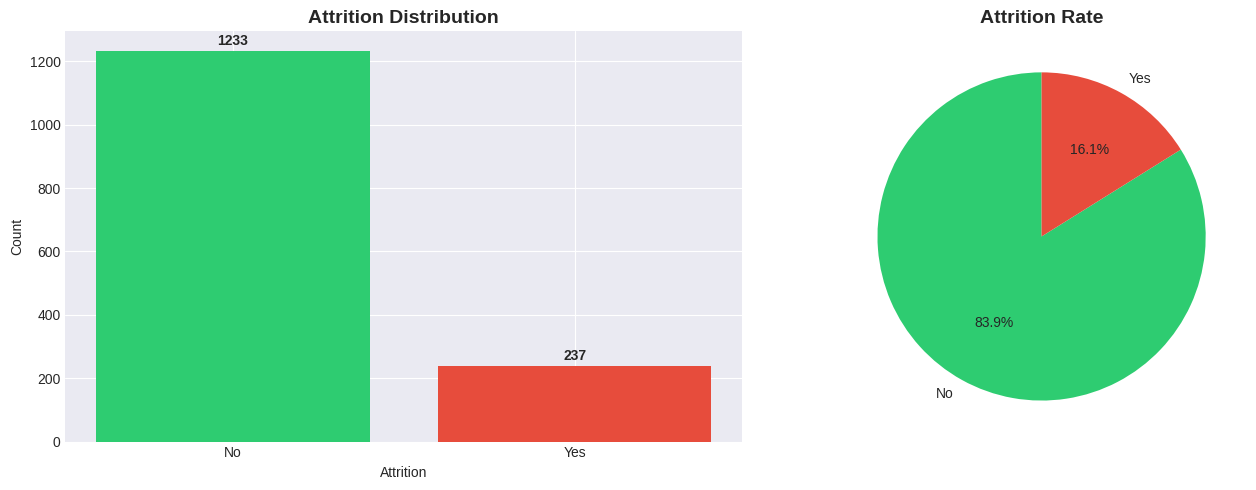


📊 Attrition Summary:
  - No Attrition: 1233 (83.9%)
  - Attrition: 237 (16.1%)


In [ ]:
  # Visualization: Attrition Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
attrition_counts = df_clean['Attrition'].value_counts()
axes[0].bar(attrition_counts.index, attrition_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Attrition Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(attrition_counts.values, labels=attrition_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Attrition Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Attrition Summary:")
print(f"  - No Attrition: {attrition_counts['No']} ({attrition_counts['No']/len(df_clean)*100:.1f}%)")
print(f"  - Attrition: {attrition_counts['Yes']} ({attrition_counts['Yes']/len(df_clean)*100:.1f}%)")

## 4.3. Phân tích Attrition theo Department

📊 Attrition by Department:
Attrition                No  Yes  Total  Attrition_Rate
Department                                             
Human Resources          51   12     63           19.05
Research & Development  828  133    961           13.84
Sales                   354   92    446           20.63


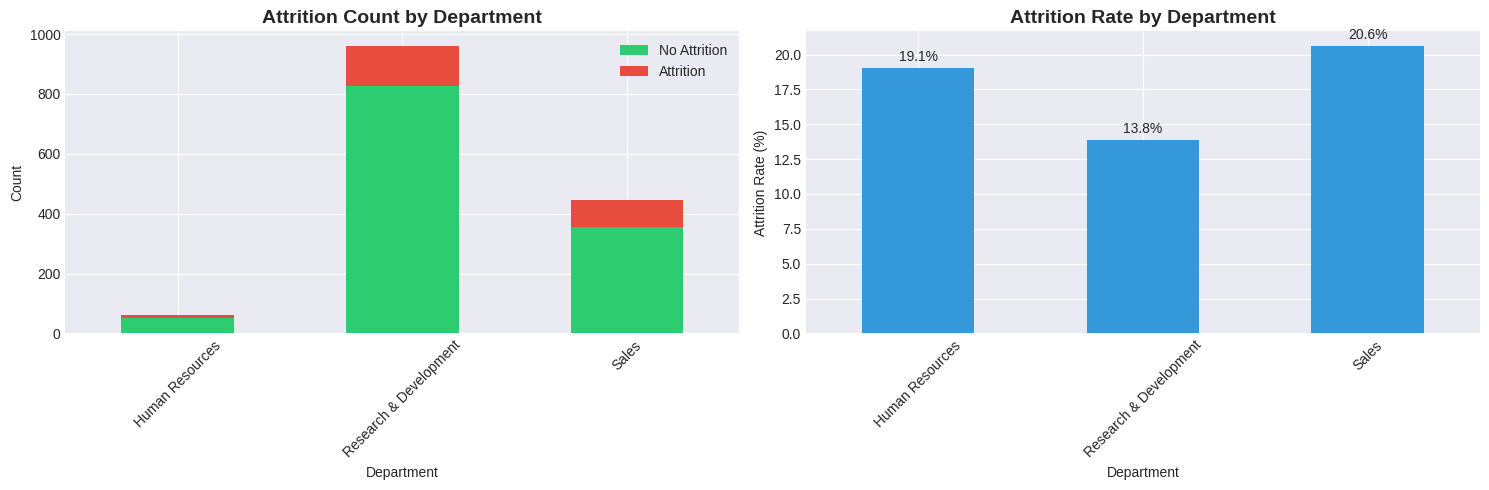

In [ ]:
# Attrition by Department
dept_attrition = df_clean.groupby(['Department', 'Attrition']).size().unstack(fill_value=0)
dept_attrition['Total'] = dept_attrition.sum(axis=1)
dept_attrition['Attrition_Rate'] = (dept_attrition['Yes'] / dept_attrition['Total'] * 100).round(2)

print("📊 Attrition by Department:")
print(dept_attrition)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stacked bar chart
dept_attrition[['No', 'Yes']].plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Attrition Count by Department', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Count')
axes[0].legend(['No Attrition', 'Attrition'])
axes[0].tick_params(axis='x', rotation=45)

# Attrition rate
dept_attrition['Attrition_Rate'].plot(kind='bar', ax=axes[1], color='#3498db')
axes[1].set_title('Attrition Rate by Department', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(dept_attrition['Attrition_Rate'].values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

**Nhận xét**
* Theo department: Bộ phận Kinh doanh (Sales) có tỷ lệ nghỉ việc cao  nhất (20.63%), tiếp theo là Nhân sự (Human Resources) với 19.05%. Bộ phận Nghiên cứu và Phát triển (R&D) có tỷ lệ thấp nhất (13.84%), cho thấy tính ổn định cao hơn.


## 4.4. Phân tích Attrition theo Job Role

📊 Attrition by Job Role:
Attrition                   No  Yes  Total  Attrition_Rate
JobRole                                                   
Sales Representative        50   33     83           39.76
Laboratory Technician      197   62    259           23.94
Human Resources             40   12     52           23.08
Sales Executive            269   57    326           17.48
Research Scientist         245   47    292           16.10
Manufacturing Director     135   10    145            6.90
Healthcare Representative  122    9    131            6.87
Manager                     97    5    102            4.90
Research Director           78    2     80            2.50


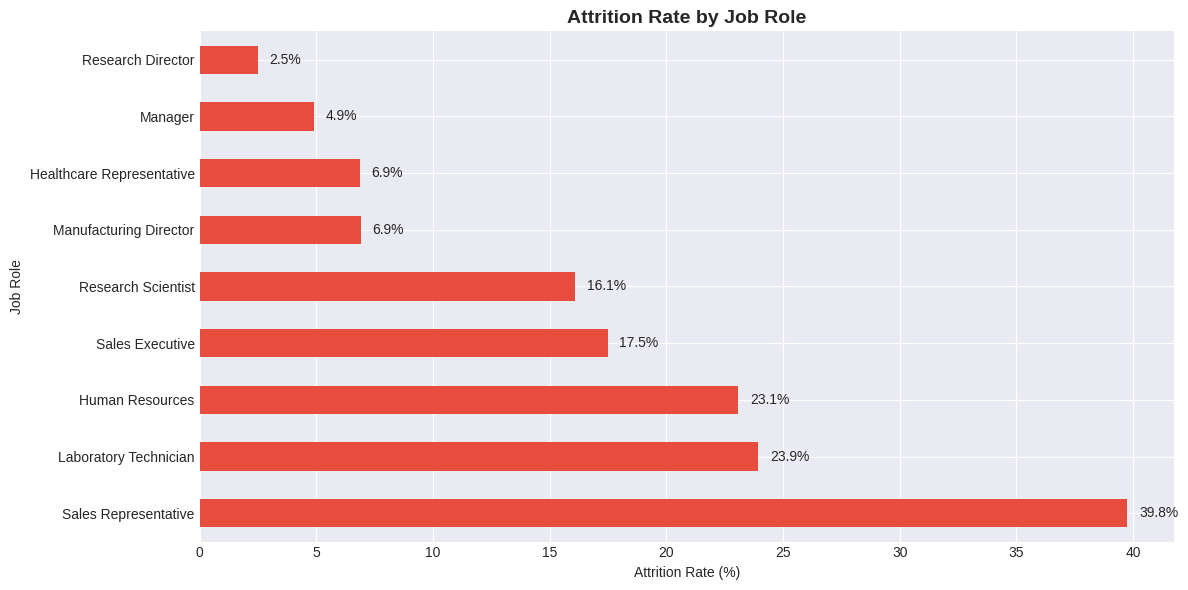

In [ ]:
# Attrition by Job Role
role_attrition = df_clean.groupby(['JobRole', 'Attrition']).size().unstack(fill_value=0)
role_attrition['Total'] = role_attrition.sum(axis=1)
role_attrition['Attrition_Rate'] = (role_attrition['Yes'] / role_attrition['Total'] * 100).round(2)
role_attrition = role_attrition.sort_values('Attrition_Rate', ascending=False)

print("📊 Attrition by Job Role:")
print(role_attrition)

# Visualization
plt.figure(figsize=(12, 6))
role_attrition['Attrition_Rate'].plot(kind='barh', color='#e74c3c')
plt.title('Attrition Rate by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
for i, v in enumerate(role_attrition['Attrition_Rate'].values):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

**Nhận xét**
* Theo vị trí: Có sự phân hóa rõ rệt. Nhóm Sales Representative có tỷ lệ nghỉ việc báo động (gần 40%), theo sau là Laboratory Technician. Ngược lại, các vị trí cấp cao như Research Director và Manager có tỷ lệ nghỉ việc rất thấp (< 5%). Điều này gợi ý rằng thâm niên và cấp bậc có quan hệ nghịch biến với khả năng nghỉ việc.

## 4.5. Phân tích Demographics

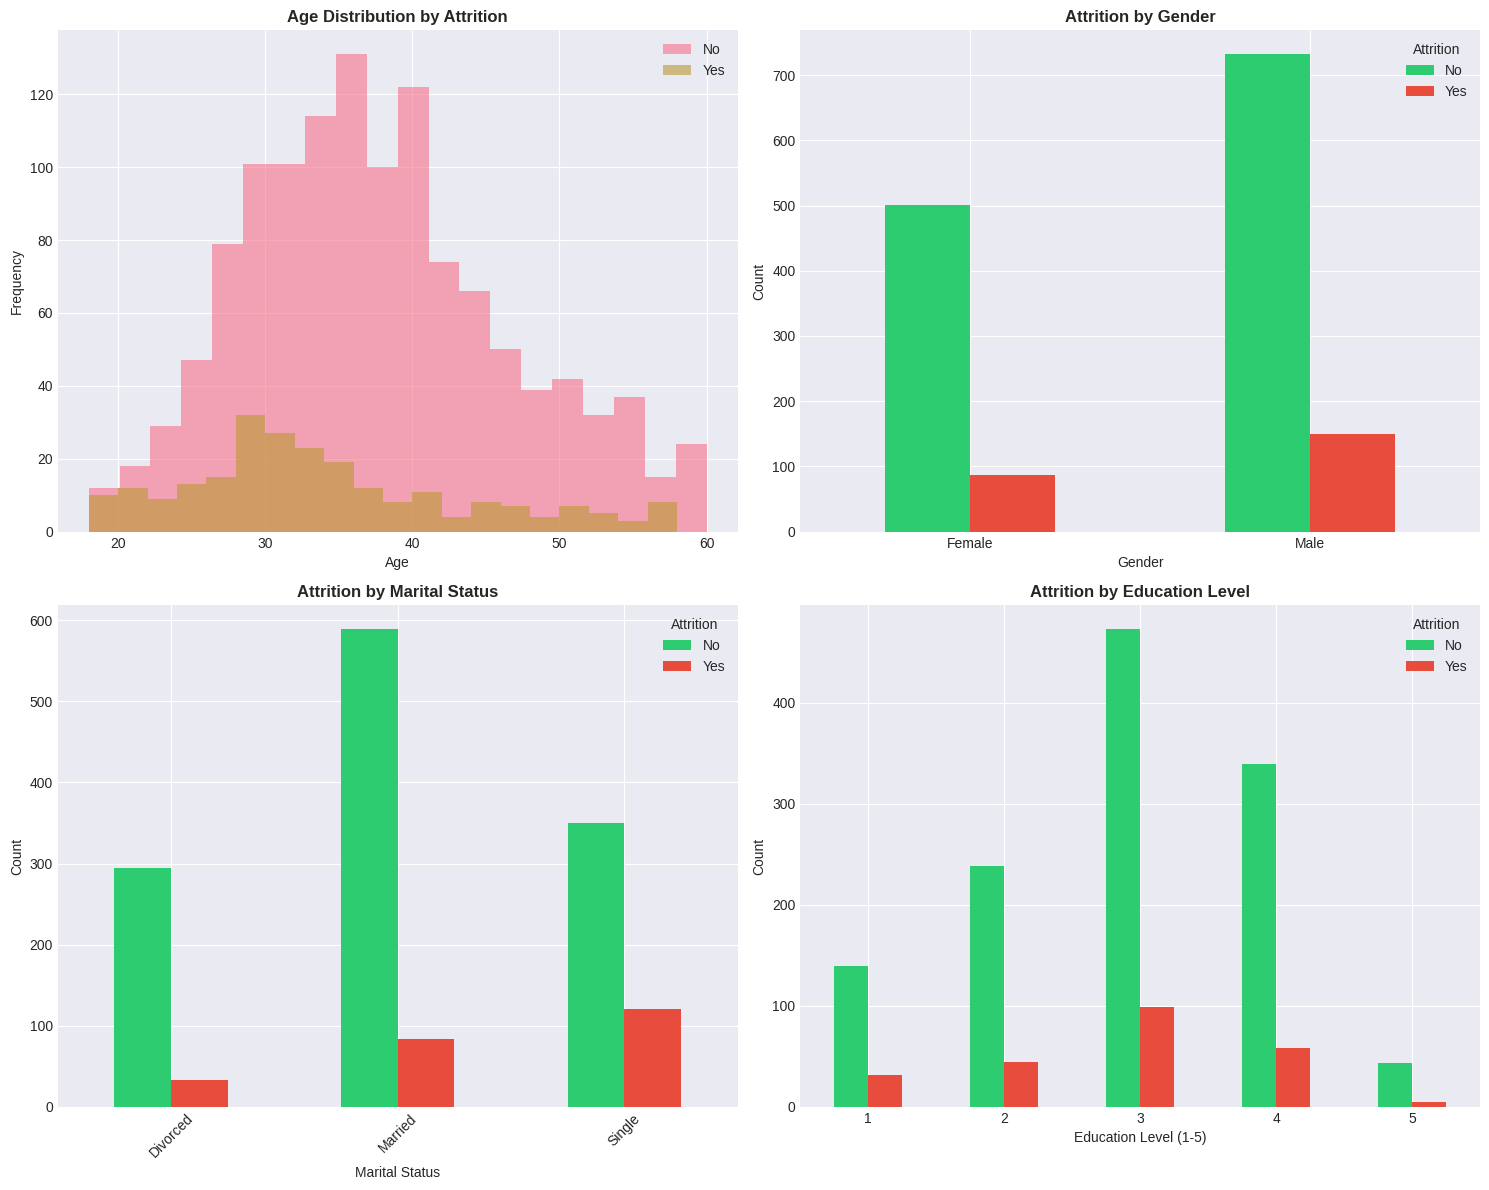

In [ ]:
# Demographics Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Age Distribution
df_clean.groupby(['Attrition'])['Age'].hist(bins=20, alpha=0.6, ax=axes[0, 0], legend=True)
axes[0, 0].set_title('Age Distribution by Attrition', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend(['No', 'Yes'])

# Gender
gender_attrition = pd.crosstab(df_clean['Gender'], df_clean['Attrition'])
gender_attrition.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('Attrition by Gender', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Gender')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=0)

# Marital Status
marital_attrition = pd.crosstab(df_clean['MaritalStatus'], df_clean['Attrition'])
marital_attrition.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Attrition by Marital Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Marital Status')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Education Level
edu_attrition = pd.crosstab(df_clean['Education'], df_clean['Attrition'])
edu_attrition.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Attrition by Education Level', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Education Level (1-5)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Nhận xét**

- Độ tuổi: Phân phối độ tuổi cho thấy nhân viên nghỉ việc tập trung nhiều ở nhóm trẻ (dưới 30 tuổi). Khi độ tuổi tăng lên, xu hướng nghỉ việc giảm dần, thể hiện sự ổn định nghề nghiệp ở lứa tuổi trung niên.

- Tình trạng hôn nhân: Nhóm nhân viên Độc thân (Single) có tỷ lệ nghỉ việc cao vượt trội so với nhóm Đã kết hôn (Married) hoặc Ly hôn (Divorced). Đây là nhóm đối tượng có ít ràng buộc gia đình và xu hướng tìm kiếm cơ hội mới cao hơn.

- Giới tính: Nam giới có số lượng nghỉ việc cao hơn nữ giới, tuy nhiên cần xem xét tỷ lệ phần trăm tương ứng với tổng số nhân viên nam/nữ để có kết luận chính xác hơn.

## 4.6. Phân tích Compensation và Satisfaction

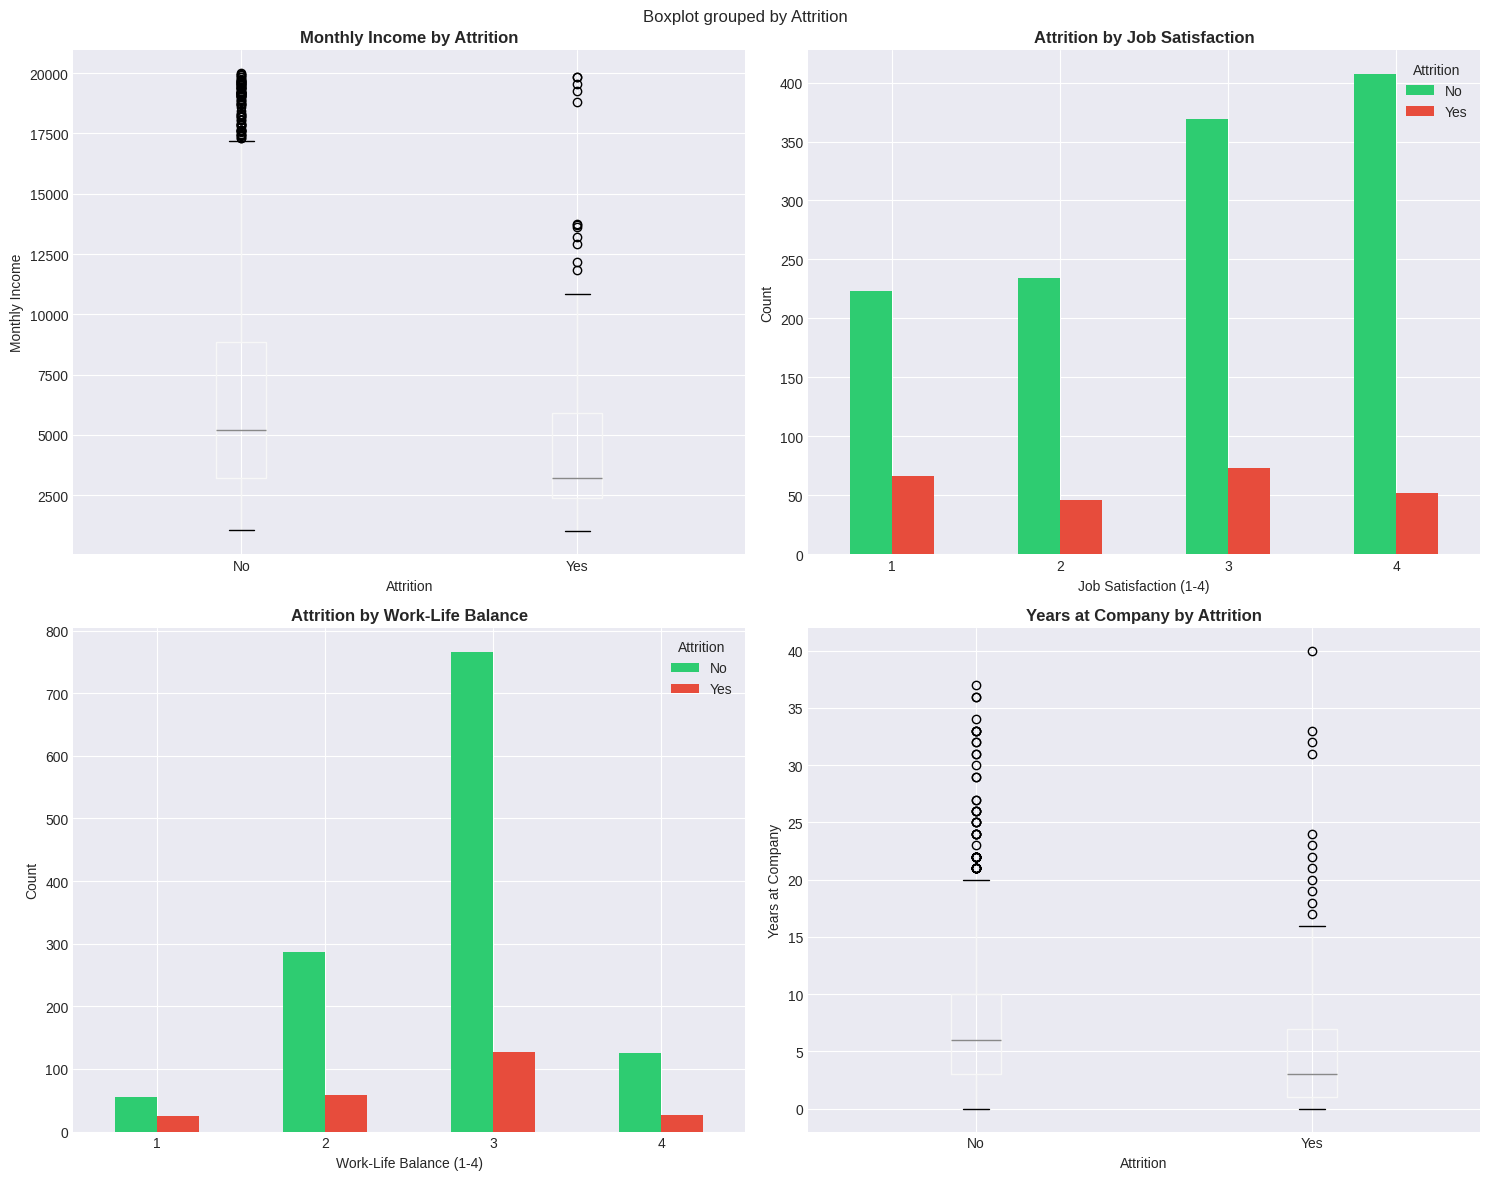

In [ ]:
  # Compensation and Satisfaction Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Monthly Income by Attrition
df_clean.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[0, 0])
axes[0, 0].set_title('Monthly Income by Attrition', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Attrition')
axes[0, 0].set_ylabel('Monthly Income')
plt.sca(axes[0, 0])
plt.xticks([1, 2], ['No', 'Yes'])

# Job Satisfaction
satisfaction_attrition = pd.crosstab(df_clean['JobSatisfaction'], df_clean['Attrition'])
satisfaction_attrition.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('Attrition by Job Satisfaction', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Job Satisfaction (1-4)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=0)

# Work Life Balance
wlb_attrition = pd.crosstab(df_clean['WorkLifeBalance'], df_clean['Attrition'])
wlb_attrition.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Attrition by Work-Life Balance', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Work-Life Balance (1-4)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=0)

# Years at Company
df_clean.boxplot(column='YearsAtCompany', by='Attrition', ax=axes[1, 1])
axes[1, 1].set_title('Years at Company by Attrition', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Attrition')
axes[1, 1].set_ylabel('Years at Company')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['No', 'Yes'])

plt.tight_layout()
plt.show()

**Nhận xét**

- Thu nhập (Monthly Income): Biểu đồ hộp (Boxplot) chỉ ra sự chênh lệch rõ ràng về trung vị thu nhập. Nhóm nghỉ việc (Yes) có mức lương trung bình thấp hơn đáng kể so với nhóm ở lại. Các điểm ngoại lai (outliers) ở nhóm nghỉ việc cho thấy vẫn có những người lương cao nghỉ việc, nhưng không phổ biến.
- Thâm niên (Years at Company): Nhân viên mới (thâm niên thấp) có xu hướng nghỉ việc cao hơn. Sau khi vượt qua mốc 5-10 năm, nhân viên thường có xu hướng gắn bó lâu
dài.
- Sự hài lòng: Mức độ hài lòng với công việc (Job Satisfaction) thấp (mức 1) tương ứng với số lượng nghỉ việc cao. Tuy nhiên, sự phân bố ở các mức 2, 3, 4 không quá chênh lệch, cho thấy sự hài lòng chỉ là một trong nhiều yếu tố.

## 4.7. Correlation Analysis

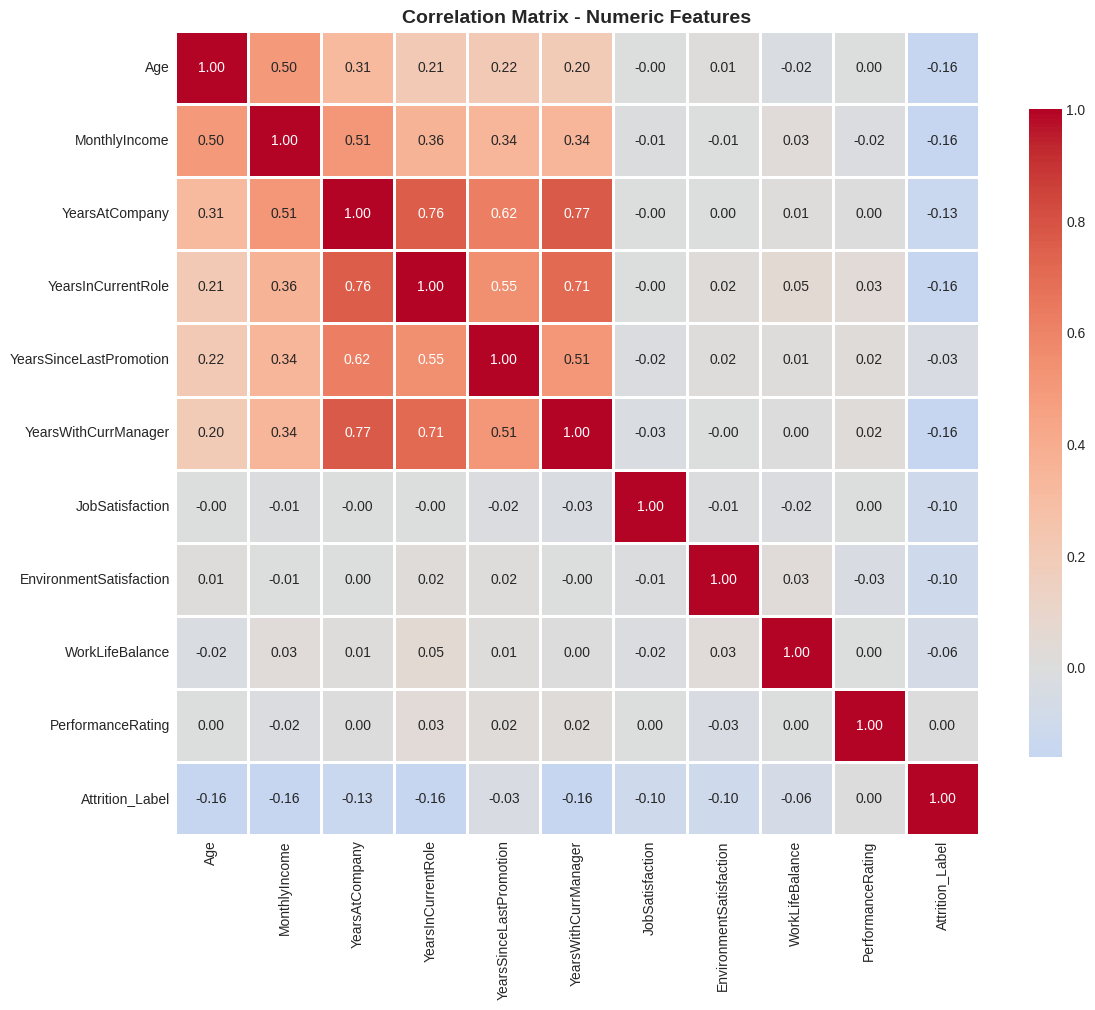


📊 Top 10 correlations with Attrition:
PerformanceRating          0.002889
YearsSinceLastPromotion   -0.033019
WorkLifeBalance           -0.063939
EnvironmentSatisfaction   -0.103369
JobSatisfaction           -0.103481
YearsAtCompany            -0.134392
YearsWithCurrManager      -0.156199
Age                       -0.159205
MonthlyIncome             -0.159840
YearsInCurrentRole        -0.160545
Name: Attrition_Label, dtype: float64


In [ ]:
# Correlation with Attrition Label
numeric_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'YearsInCurrentRole',
                    'YearsSinceLastPromotion', 'YearsWithCurrManager',
                    'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance',
                    'PerformanceRating', 'Attrition_Label']

corr_matrix = df_clean[numeric_features].corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with attrition
print("\n📊 Top 10 correlations with Attrition:")
attrition_corr = corr_matrix['Attrition_Label'].sort_values(ascending=False)
print(attrition_corr[attrition_corr.index != 'Attrition_Label'].head(10))

**Nhận xét:**
- Đa cộng tuyến (Multicollinearity): Có sự tương quan rất mạnh giữa MonthlyIncome và JobLevel (hệ số ≈ 0.95), cũng như giữa YearsAtCompany và YearsWithCurrManager. Điều này cảnh báo về hiện tượng đa cộng tuyến, cần được xử lý khi sử dụng các mô hình
như Logistic Regression (nhạy cảm với đa cộng tuyến).
- Tương quan với Attrition: Các biến có tương quan nghịch biến mạnh nhất với việc nghỉ việc là TotalWorkingYears, JobLevel, MonthlyIncome, và Age. Điều này khẳng định lại giả thuyết: Nhân viên càng lớn tuổi, lương càng cao và thâm niên càng lớn thì càng ít có
khả năng nghỉ việc.

# 5. RÚT GỌN DỮ LIỆU
Việc giảm xuống còn 7 thuộc tính (Features) sẽ giúp:

- Demo Streamlit cực kỳ gọn: Người dùng không phải nhập mỏi tay.

- Code xử lý đơn giản: Ít lỗi encoding, ít lỗi null.

- Vẫn đảm bảo độ chính xác: Vì nguyên tắc Pareto (80/20), 20% số biến quan trọng nhất quyết định 80% kết quả.

| STT | Tên thuộc tính | Kiểu dữ liệu | Lý do chọn |
|-------|-------|-------|-------|
| 1 | OverTime  |   Yes/No   | Quan trọng nhất. Người làm thêm giờ có nguy cơ nghỉ việc cao gấp 3 lần. Nếu bỏ biến này, model sẽ phế.|
| 2     | MonthlyIncome     | int  |  Động lực tài chính. Lương thấp là nguyên nhân hàng đầu khiến nhân viên ra đi.    |
| 3     | Age     | int     | Yếu tố thế hệ. Nhóm Gen Z (dưới 30) nhảy việc nhiều hơn hẳn nhóm Senior.|
| 4     | TotalWorkingYears     | int     | Kinh nghiệm. Người mới đi làm hay nhảy việc, người làm lâu năm ngại thay đổi. |
| 5     | YearsAtCompany     | int     | Sự thâm niên. Biến này giúp phân biệt "lính mới" và "công thần" tại công ty hiện tại.     |
| 6     | JobSatisfaction     | 1 -> 4     | Yếu tố tâm lý. Lương cao mà chán việc (Mức 1) thì vẫn nghỉ như thường.     |
| 7     | MaritalStatus     | Object     | Yếu tố gia đình. Người độc thân (Single) tự do hơn và dễ nhảy việc hơn người đã lập gia đình.     |

In [ ]:
selected_columns = [
        'Attrition',           # Target
        'OverTime',            # Feature 1
        'MonthlyIncome',       # Feature 2
        'Age',                 # Feature 3
        'TotalWorkingYears',   # Feature 4
        'YearsAtCompany',      # Feature 5
        'JobSatisfaction',     # Feature 6
        'MaritalStatus'        # Feature 7
    ]

df_reduce = df[selected_columns]

In [ ]:
df_reduce.head()

,Attrition,OverTime,MonthlyIncome,Age,TotalWorkingYears,YearsAtCompany,JobSatisfaction,MaritalStatus
0,Yes,Yes,5993,41,8,6,4,Single
1,No,No,5130,49,10,10,2,Married
2,Yes,Yes,2090,37,7,0,3,Single
3,No,Yes,2909,33,8,8,3,Married
4,No,No,3468,27,6,2,2,Married


In [ ]:
# Binary Encoding (Yes/No -> 1/0)
df_reduce['Attrition'] = df_reduce['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
df_reduce['OverTime'] = df_reduce['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

/tmp/ipython-input-1738218829.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reduce['Attrition'] = df_reduce['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
/tmp/ipython-input-1738218829.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reduce['OverTime'] = df_reduce['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)


In [ ]:
# 3.2 One-Hot Encoding cho MaritalStatus (Single/Married/Divorced)
# drop_first=True để tránh đa cộng tuyến (Ví dụ: Nếu không phải Single và Married thì chắc chắn là Divorced)
df_reduce = pd.get_dummies(df_reduce, columns=['MaritalStatus'], drop_first=True)


print("✓ Đã mã hóa xong dữ liệu (One-Hot & Binary)")
print("   Các cột hiện tại:", list(df_reduce.columns))

✓ Đã mã hóa xong dữ liệu (One-Hot & Binary)
   Các cột hiện tại: ['Attrition', 'OverTime', 'MonthlyIncome', 'Age', 'TotalWorkingYears', 'YearsAtCompany', 'JobSatisfaction', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [ ]:
df_reduce.head()

,Attrition,OverTime,MonthlyIncome,Age,TotalWorkingYears,YearsAtCompany,JobSatisfaction,MaritalStatus_Married,MaritalStatus_Single
0,1,1,5993,41,8,6,4,False,True
1,0,0,5130,49,10,10,2,True,False
2,1,1,2090,37,7,0,3,False,True
3,0,1,2909,33,8,8,3,True,False
4,0,0,3468,27,6,2,2,True,False


In [ ]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# 4. CHIA TẬP TRAIN / TEST
X = df_reduce.drop('Attrition', axis=1)
y = df_reduce['Attrition']

# Chia 80% Train - 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"✓ Đã chia dữ liệu: Train={X_train.shape}, Test={X_test.shape}")

✓ Đã chia dữ liệu: Train=(1176, 8), Test=(294, 8)


In [ ]:
# CHUẨN HÓA DỮ LIỆU (SCALING)
# Chỉ scale các cột số thực, tránh làm hỏng các cột 0/1 (như OverTime)
numeric_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'JobSatisfaction']

In [ ]:
scaler = StandardScaler()
# Fit trên Train và Transform cả Train lẫn Test
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
print("✓ Đã chuẩn hóa (Scaling) các cột số liệu.")

✓ Đã chuẩn hóa (Scaling) các cột số liệu.


In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
# 6. XỬ LÝ MẤT CÂN BẰNG (SMOTE) - CHỈ TRÊN TẬP TRAIN
print(f"   [Trước SMOTE] Số lượng nghỉ việc (1) trong Train: {sum(y_train)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"   [Sau SMOTE]   Số lượng nghỉ việc (1) trong Train: {sum(y_train_resampled)}")
print("✓ Đã cân bằng dữ liệu thành công!")

   [Trước SMOTE] Số lượng nghỉ việc (1) trong Train: 190
   [Sau SMOTE]   Số lượng nghỉ việc (1) trong Train: 986
✓ Đã cân bằng dữ liệu thành công!


In [ ]:
# LƯU CÁC FILE QUAN TRỌNG (.PKL)
OUTPUT_DIR =  "/content/drive/MyDrive/AIO_Warm Up_REVIEW/AIO_The Liems/CONQ002"
# Lưu dataset đã xử lý (để dùng cho file training)
joblib.dump((X_train_resampled, y_train_resampled), f'{OUTPUT_DIR}/train_data.pkl')
joblib.dump((X_test, y_test), f'{OUTPUT_DIR}/test_data.pkl')

# Lưu Scaler (Để App dùng convert input người dùng)
joblib.dump(scaler, f'{OUTPUT_DIR}/scaler.pkl')

# Lưu danh sách cột cuối cùng (Để App tạo dataframe đúng thứ tự)
joblib.dump(X.columns.tolist(), f'{OUTPUT_DIR}/model_columns.pkl')

print("\n✅ HOÀN TẤT! File đã được lưu vào thư mục 'models/'.")


✅ HOÀN TẤT! File đã được lưu vào thư mục 'models/'.


# 6. HUẤN LUYỆN CHO BỘ DỮ LIỆU ĐÃ RÚT GỌN

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [ ]:
MODEL_DIR = "/content/drive/MyDrive/AIO_Warm Up_REVIEW/AIO_The Liems/CONQ002"

In [ ]:
def load_processed_data():
    """Đọc dữ liệu đã qua xử lý từ file .pkl"""
    print("📂 Đang tải dữ liệu từ thư mục 'models/'...")

    # Load dữ liệu Train (đã SMOTE) và Test (nguyên bản)
    X_train, y_train = joblib.load(f'{MODEL_DIR}/train_data.pkl')
    X_test, y_test = joblib.load(f'{MODEL_DIR}/test_data.pkl')

    print(f"   Train set: {X_train.shape}")
    print(f"   Test set:  {X_test.shape}")
    return X_train, X_test, y_train, y_test

def evaluate_model(name, model, X_test, y_test):
    """Hàm đánh giá và in kết quả"""
    print(f"\n{'='*20} {name} {'='*20}")

    # Dự báo
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Xác suất nghỉ việc

    # Tính các chỉ số
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print(f"✅ Accuracy (Độ chính xác): {acc:.2%}")
    print(f"✅ ROC-AUC Score:          {roc:.4f}")
    print("\n📊 Classification Report:\n")
    print(classification_report(y_test, y_pred))

    print("🧩 Confusion Matrix (Ma trận nhầm lẫn):")
    print(confusion_matrix(y_test, y_pred))

    return acc

def train():
    # 1. Load dữ liệu
    X_train, X_test, y_train, y_test = load_processed_data()

    # 2. Huấn luyện Logistic Regression (Mô hình cơ sở)
    print("\n🚀 Đang huấn luyện Logistic Regression...")
    log_reg = LogisticRegression(max_iter=1000, random_state=42)
    log_reg.fit(X_train, y_train)

    evaluate_model("Logistic Regression", log_reg, X_test, y_test)

    # 3. Huấn luyện Random Forest (Mô hình chính)
    print("\n🌲 Đang huấn luyện Random Forest...")
    rf_model = RandomForestClassifier(
        n_estimators=100,    # Số lượng cây
        max_depth=10,        # Độ sâu tối đa để tránh học vẹt (overfitting)
        random_state=42,
        n_jobs=-1            # Dùng tất cả nhân CPU
    )
    rf_model.fit(X_train, y_train)

    evaluate_model("Random Forest", rf_model, X_test, y_test)

    # 4. Lưu mô hình tốt nhất (Random Forest thường tốt hơn)
    print(f"\n💾 Đang lưu mô hình vào '{MODEL_DIR}'...")

    joblib.dump(rf_model, f'{MODEL_DIR}/rf_model.pkl')
    joblib.dump(log_reg, f'{MODEL_DIR}/logreg_model.pkl')

    print("✅ HOÀN TẤT! Đã lưu 'rf_model.pkl' và 'logreg_model.pkl'.")

if __name__ == "__main__":
    train()

📂 Đang tải dữ liệu từ thư mục 'models/'...
   Train set: (1972, 8)
   Test set:  (294, 8)

🚀 Đang huấn luyện Logistic Regression...

==================== Logistic Regression ====================
✅ Accuracy (Độ chính xác): 69.73%
✅ ROC-AUC Score:          0.7834

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.69      0.79       247
           1       0.31      0.74      0.44        47

    accuracy                           0.70       294
   macro avg       0.62      0.72      0.62       294
weighted avg       0.83      0.70      0.74       294

🧩 Confusion Matrix (Ma trận nhầm lẫn):
[[170  77]
 [ 12  35]]

🌲 Đang huấn luyện Random Forest...

==================== Random Forest ====================
✅ Accuracy (Độ chính xác): 79.59%
✅ ROC-AUC Score:          0.7431

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.86      0.88       247
           1       0.38   